# Phân tích Dataset VSL v2 — Bảng chữ cái tiếng Việt
**Dataset:** [VSL v2](https://www.kaggle.com/datasets/cuongnk9104/vsl-v2)  
**Mục tiêu:** Nhận dạng ký hiệu bảng chữ cái tiếng Việt từ ảnh tĩnh

### Mục lục
1. Setup & Load
2. Cấu trúc Dataset
3. Phân bố Class
4. Phân tích Ảnh (kích thước, kênh màu, định dạng)
5. Phân tích nội dung ảnh (brightness, contrast, blur)
6. Phân tích Keypoints (nếu ảnh là skeleton)
7. Phân tích chất lượng dữ liệu
8. Train/Val/Test Split đề xuất
9. Tổng hợp & Đề xuất

## 1. Setup & Load

In [3]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
import hashlib
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
random.seed(42)
np.random.seed(42)

# ── Đường dẫn dataset ──────────────────────────────────────────────────────
# Thay đổi ROOT cho phù hợp với môi trường của bạn
ROOT = Path('/kaggle/input/datasets/cuongnk9104/vsl-v2/v2')   # Kaggle
# ROOT = Path('./v2')                     # Local

OUT = Path('.')
print(f'ROOT exists: {ROOT.exists()}')
print(f'Subfolders: {[p.name for p in sorted(ROOT.iterdir()) if p.is_dir()]}')

ROOT exists: True
Subfolders: ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'Râu', 'S', 'T', 'U', 'V', 'X', 'Y', 'mũ', 'Đ']


## 2. Cấu trúc Dataset

In [4]:
# ── Quét toàn bộ dataset ───────────────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

records = []
for class_dir in sorted(ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    imgs = [f for f in class_dir.iterdir() if f.suffix.lower() in IMG_EXTS]
    for img_path in imgs:
        records.append({
            'class':     class_name,
            'filename':  img_path.name,
            'path':      str(img_path),
            'ext':       img_path.suffix.lower(),
            'size_kb':   img_path.stat().st_size / 1024,
        })

df = pd.DataFrame(records)

print('=' * 60)
print('CẤU TRÚC DATASET VSL v2')
print('=' * 60)
print(f"""
Tổng số class       : {df['class'].nunique()}
Tổng số ảnh         : {len(df):,}
Định dạng ảnh       : {df['ext'].value_counts().to_dict()}
Dung lượng trung bình: {df['size_kb'].mean():.1f} KB / ảnh
Tổng dung lượng     : {df['size_kb'].sum() / 1024:.1f} MB
""")

print('Danh sách class:')
print(sorted(df['class'].unique()))

CẤU TRÚC DATASET VSL v2

Tổng số class       : 25
Tổng số ảnh         : 58,439
Định dạng ảnh       : {'.jpeg': 58439}
Dung lượng trung bình: 11.0 KB / ảnh
Tổng dung lượng     : 628.8 MB

Danh sách class:
['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'Râu', 'S', 'T', 'U', 'V', 'X', 'Y', 'mũ', 'Đ']


In [5]:
# ── Cấu trúc thư mục dạng tree ────────────────────────────────────────────
per_class = df.groupby('class').size().sort_values(ascending=False)

print(f'{'CLASS':<12} {'N_IMAGES':>10} {'BAR'}')
print('-' * 60)
for cls, n in per_class.items():
    bar = '█' * int(n / per_class.max() * 40)
    print(f'{cls:<12} {n:>10,}  {bar}')

CLASS          N_IMAGES BAR
------------------------------------------------------------
O                 2,578  ████████████████████████████████████████
P                 2,523  ███████████████████████████████████████
E                 2,491  ██████████████████████████████████████
Q                 2,479  ██████████████████████████████████████
I                 2,453  ██████████████████████████████████████
Râu               2,431  █████████████████████████████████████
C                 2,430  █████████████████████████████████████
G                 2,425  █████████████████████████████████████
K                 2,419  █████████████████████████████████████
T                 2,414  █████████████████████████████████████
S                 2,413  █████████████████████████████████████
H                 2,413  █████████████████████████████████████
B                 2,412  █████████████████████████████████████
L                 2,410  █████████████████████████████████████
D                 2,4

## 3. Phân bố Class

PHÂN BỐ ẢNH THEO CLASS

Min ảnh / class  : 1815 (U)
Max ảnh / class  : 2578 (O)
Mean ảnh / class : 2337.6
Median           : 2412.0
Std              : 200.7

Imbalance ratio (max/min): 1.42x
→ ✅ Dataset khá cân bằng


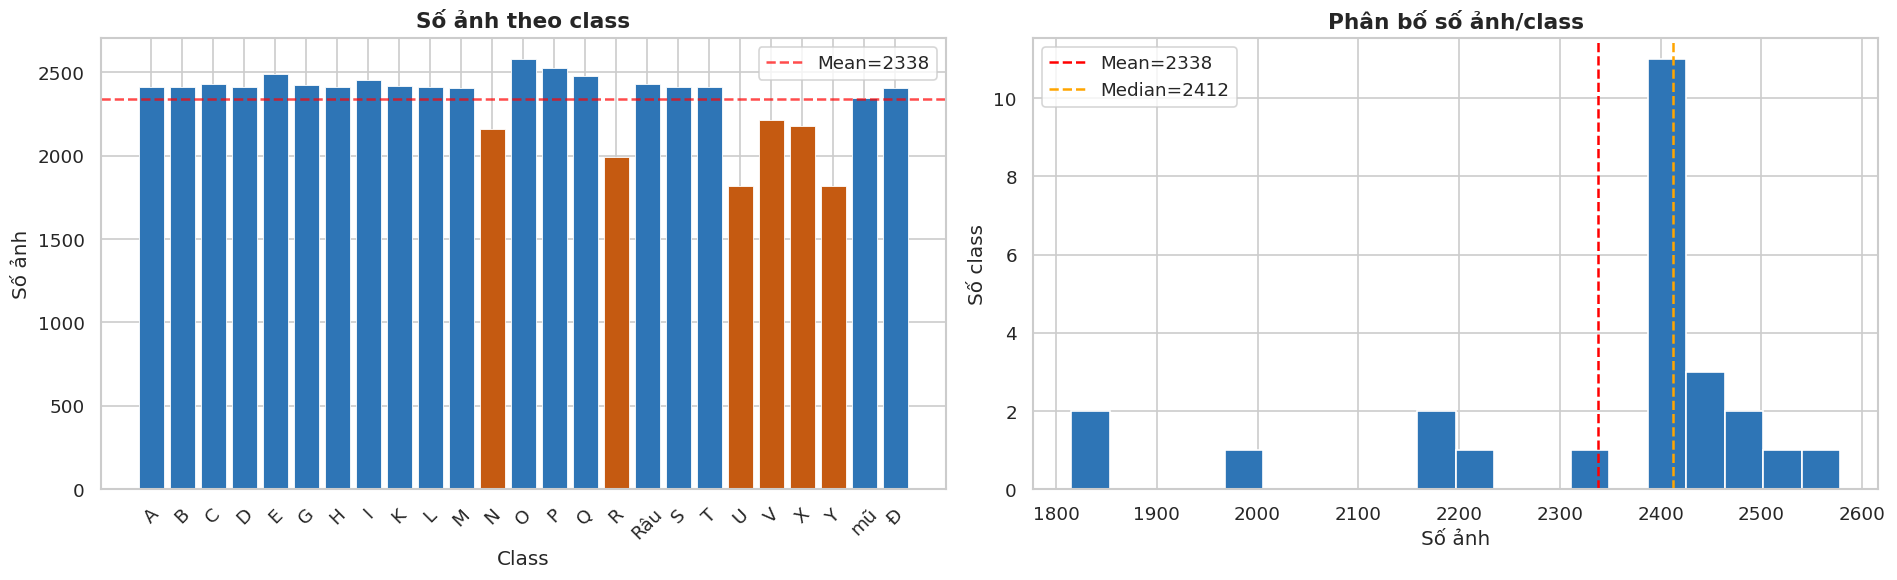

Saved: class_distribution.png


In [6]:
per_class = df.groupby('class').size().sort_index()

print('=' * 60)
print('PHÂN BỐ ẢNH THEO CLASS')
print('=' * 60)
print(f"""
Min ảnh / class  : {per_class.min()} ({per_class.idxmin()})
Max ảnh / class  : {per_class.max()} ({per_class.idxmax()})
Mean ảnh / class : {per_class.mean():.1f}
Median           : {per_class.median():.1f}
Std              : {per_class.std():.1f}
""")

# Kiểm tra mức độ cân bằng
imbalance_ratio = per_class.max() / per_class.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}x')
if imbalance_ratio < 2:
    print('→ ✅ Dataset khá cân bằng')
elif imbalance_ratio < 5:
    print('→ ⚠ Dataset có chênh lệch vừa phải')
else:
    print('→ ❌ Dataset mất cân bằng nghiêm trọng')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#2E75B6' if v >= per_class.mean() else '#C55A11' for v in per_class.values]
axes[0].bar(per_class.index, per_class.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(per_class.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean={per_class.mean():.0f}')
axes[0].set_title('Số ảnh theo class', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Số ảnh')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Histogram phân bố
axes[1].hist(per_class.values, bins=20, color='#2E75B6', edgecolor='white')
axes[1].axvline(per_class.mean(), color='red', linestyle='--', label=f'Mean={per_class.mean():.0f}')
axes[1].axvline(per_class.median(), color='orange', linestyle='--', label=f'Median={per_class.median():.0f}')
axes[1].set_title('Phân bố số ảnh/class', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Số ảnh')
axes[1].set_ylabel('Số class')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

## 4. Phân tích Ảnh (kích thước, kênh màu, định dạng)

In [7]:
# ── Đọc metadata ảnh (sample 500 ảnh mỗi class hoặc toàn bộ nếu nhỏ) ─────
SAMPLE_PER_CLASS = 30  # Điều chỉnh nếu dataset lớn

img_records = []
sample_df = df.groupby('class').apply(
    lambda x: x.sample(min(len(x), SAMPLE_PER_CLASS), random_state=42)
).reset_index(drop=True)

print(f'Đọc metadata {len(sample_df)} ảnh mẫu...')

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    try:
        img = cv2.imread(row['path'])
        if img is None:
            img_records.append({**row, 'h': None, 'w': None, 'channels': None,
                                 'is_grayscale': None, 'corrupt': True})
            continue
        h, w = img.shape[:2]
        channels = img.shape[2] if len(img.shape) == 3 else 1
        # Kiểm tra có phải grayscale không (3 channel nhưng R=G=B)
        is_gray = False
        if channels == 3:
            b, g, r = cv2.split(img)
            is_gray = (np.array_equal(b, g) and np.array_equal(g, r))
        elif channels == 1:
            is_gray = True
        img_records.append({
            **row,
            'h': h, 'w': w, 'channels': channels,
            'is_grayscale': is_gray,
            'corrupt': False,
            'aspect': round(w / h, 3),
        })
    except Exception as e:
        img_records.append({**row, 'h': None, 'w': None, 'channels': None,
                             'is_grayscale': None, 'corrupt': True})

idf = pd.DataFrame(img_records)
valid = idf[~idf['corrupt']]

print('\n' + '=' * 60)
print('THỐNG KÊ KÍCH THƯỚC ẢNH')
print('=' * 60)
print(f"""
Ảnh hợp lệ          : {len(valid):,} / {len(idf):,}
Ảnh lỗi / corrupt   : {idf['corrupt'].sum()}

Width  — mean: {valid['w'].mean():.0f}px | min: {valid['w'].min()}px | max: {valid['w'].max()}px
Height — mean: {valid['h'].mean():.0f}px | min: {valid['h'].min()}px | max: {valid['h'].max()}px
Aspect ratio — mean: {valid['aspect'].mean():.3f} | std: {valid['aspect'].std():.3f}

Số channel:
{valid['channels'].value_counts().to_string()}

Ảnh grayscale thực sự: {valid['is_grayscale'].sum()} ({valid['is_grayscale'].mean()*100:.1f}%)
""")

# Phân bố kích thước unique
size_counts = valid.groupby(['w','h']).size().reset_index(name='count').sort_values('count', ascending=False)
print('Top 10 kích thước phổ biến nhất:')
print(size_counts.head(10).to_string(index=False))

Đọc metadata 750 ảnh mẫu...


  0%|          | 0/750 [00:00<?, ?it/s]


THỐNG KÊ KÍCH THƯỚC ẢNH

Ảnh hợp lệ          : 750 / 750
Ảnh lỗi / corrupt   : 0

Width  — mean: 224px | min: 224px | max: 224px
Height — mean: 224px | min: 224px | max: 224px
Aspect ratio — mean: 1.000 | std: 0.000

Số channel:
channels
3    750

Ảnh grayscale thực sự: 750 (100.0%)

Top 10 kích thước phổ biến nhất:
  w   h  count
224 224    750


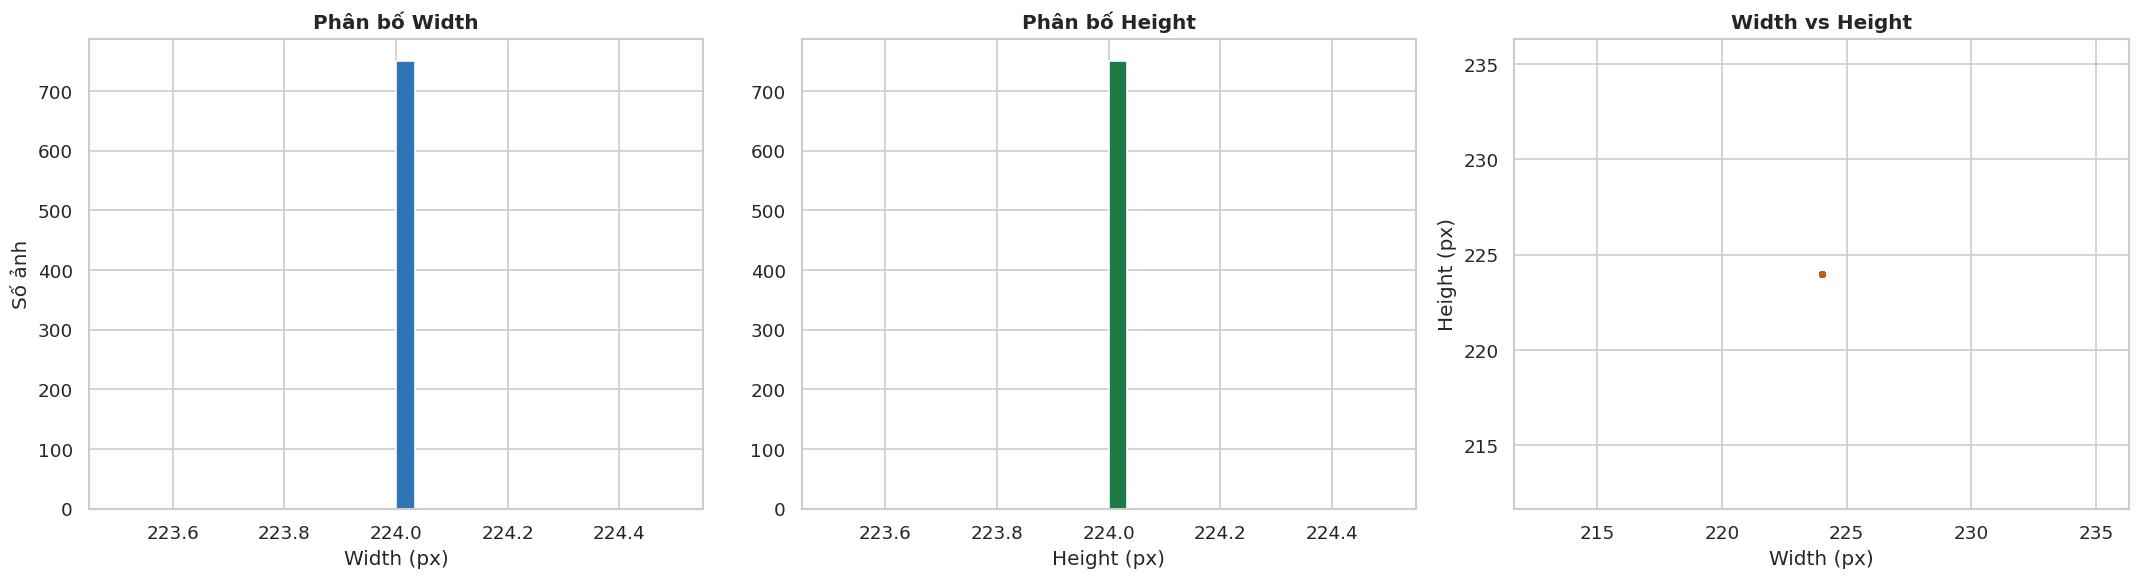

In [8]:
# ── Visualize phân bố kích thước ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(valid['w'], bins=30, color='#2E75B6', edgecolor='white')
axes[0].set_title('Phân bố Width', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Số ảnh')

axes[1].hist(valid['h'], bins=30, color='#1D7A45', edgecolor='white')
axes[1].set_title('Phân bố Height', fontweight='bold')
axes[1].set_xlabel('Height (px)')

axes[2].scatter(valid['w'], valid['h'], alpha=0.3, s=10, color='#C55A11')
axes[2].set_title('Width vs Height', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.tight_layout()
plt.savefig(OUT / 'image_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Phân tích nội dung ảnh (Brightness, Contrast, Blur)

In [9]:
# ── Tính brightness, contrast, blur cho sample ───────────────────────────
print('Phân tích brightness / contrast / blur...')

quality_records = []
for _, row in tqdm(valid.iterrows(), total=len(valid)):
    try:
        img = cv2.imread(row['path'])
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness   = float(gray.mean())
        contrast     = float(gray.std())
        # Laplacian variance — thấp = blur
        blur_score   = float(cv2.Laplacian(gray, cv2.CV_64F).var())
        # Tỉ lệ pixel trắng (background)
        white_pct    = float((gray > 240).mean() * 100)
        # Tỉ lệ pixel đen
        black_pct    = float((gray < 15).mean() * 100)

        quality_records.append({
            'class': row['class'],
            'path': row['path'],
            'brightness': brightness,
            'contrast': contrast,
            'blur_score': blur_score,
            'white_pct': white_pct,
            'black_pct': black_pct,
        })
    except:
        pass

qdf = pd.DataFrame(quality_records)

print('\n' + '=' * 60)
print('THỐNG KÊ CHẤT LƯỢNG ẢNH')
print('=' * 60)
print(f"""
Brightness (mean pixel 0-255):
  Mean: {qdf['brightness'].mean():.1f} | Std: {qdf['brightness'].std():.1f}
  Min:  {qdf['brightness'].min():.1f} | Max: {qdf['brightness'].max():.1f}

Contrast (std pixel):
  Mean: {qdf['contrast'].mean():.1f} | Std: {qdf['contrast'].std():.1f}

Blur score (Laplacian var — thấp = mờ):
  Mean: {qdf['blur_score'].mean():.1f} | Min: {qdf['blur_score'].min():.1f}
  Ảnh blur (<50):  {(qdf['blur_score'] < 50).sum()} ({(qdf['blur_score'] < 50).mean()*100:.1f}%)
  Ảnh blur (<100): {(qdf['blur_score'] < 100).sum()} ({(qdf['blur_score'] < 100).mean()*100:.1f}%)

Tỉ lệ pixel trắng (background >240):
  Mean: {qdf['white_pct'].mean():.1f}% | Max: {qdf['white_pct'].max():.1f}%

Tỉ lệ pixel đen (<15):
  Mean: {qdf['black_pct'].mean():.1f}% | Max: {qdf['black_pct'].max():.1f}%
""")

# Phán đoán loại ảnh
avg_brightness = qdf['brightness'].mean()
avg_white = qdf['white_pct'].mean()
avg_black = qdf['black_pct'].mean()

print('\n📋 Phán đoán loại ảnh:')
if avg_black > 30 and avg_brightness < 80:
    print('→ Khả năng cao là ảnh SKELETON trên nền đen (như ảnh mẫu đã thấy)')
elif avg_white > 40:
    print('→ Khả năng là ảnh tay thật trên nền trắng')
else:
    print('→ Ảnh tay thật với background đa dạng')

Phân tích brightness / contrast / blur...


  0%|          | 0/750 [00:00<?, ?it/s]


THỐNG KÊ CHẤT LƯỢNG ẢNH

Brightness (mean pixel 0-255):
  Mean: 14.0 | Std: 2.1
  Min:  9.1 | Max: 19.7

Contrast (std pixel):
  Mean: 53.5 | Std: 4.4

Blur score (Laplacian var — thấp = mờ):
  Mean: 8075.8 | Min: 4991.1
  Ảnh blur (<50):  0 (0.0%)
  Ảnh blur (<100): 0 (0.0%)

Tỉ lệ pixel trắng (background >240):
  Mean: 4.5% | Max: 6.7%

Tỉ lệ pixel đen (<15):
  Mean: 92.2% | Max: 94.3%


📋 Phán đoán loại ảnh:
→ Khả năng cao là ảnh SKELETON trên nền đen (như ảnh mẫu đã thấy)


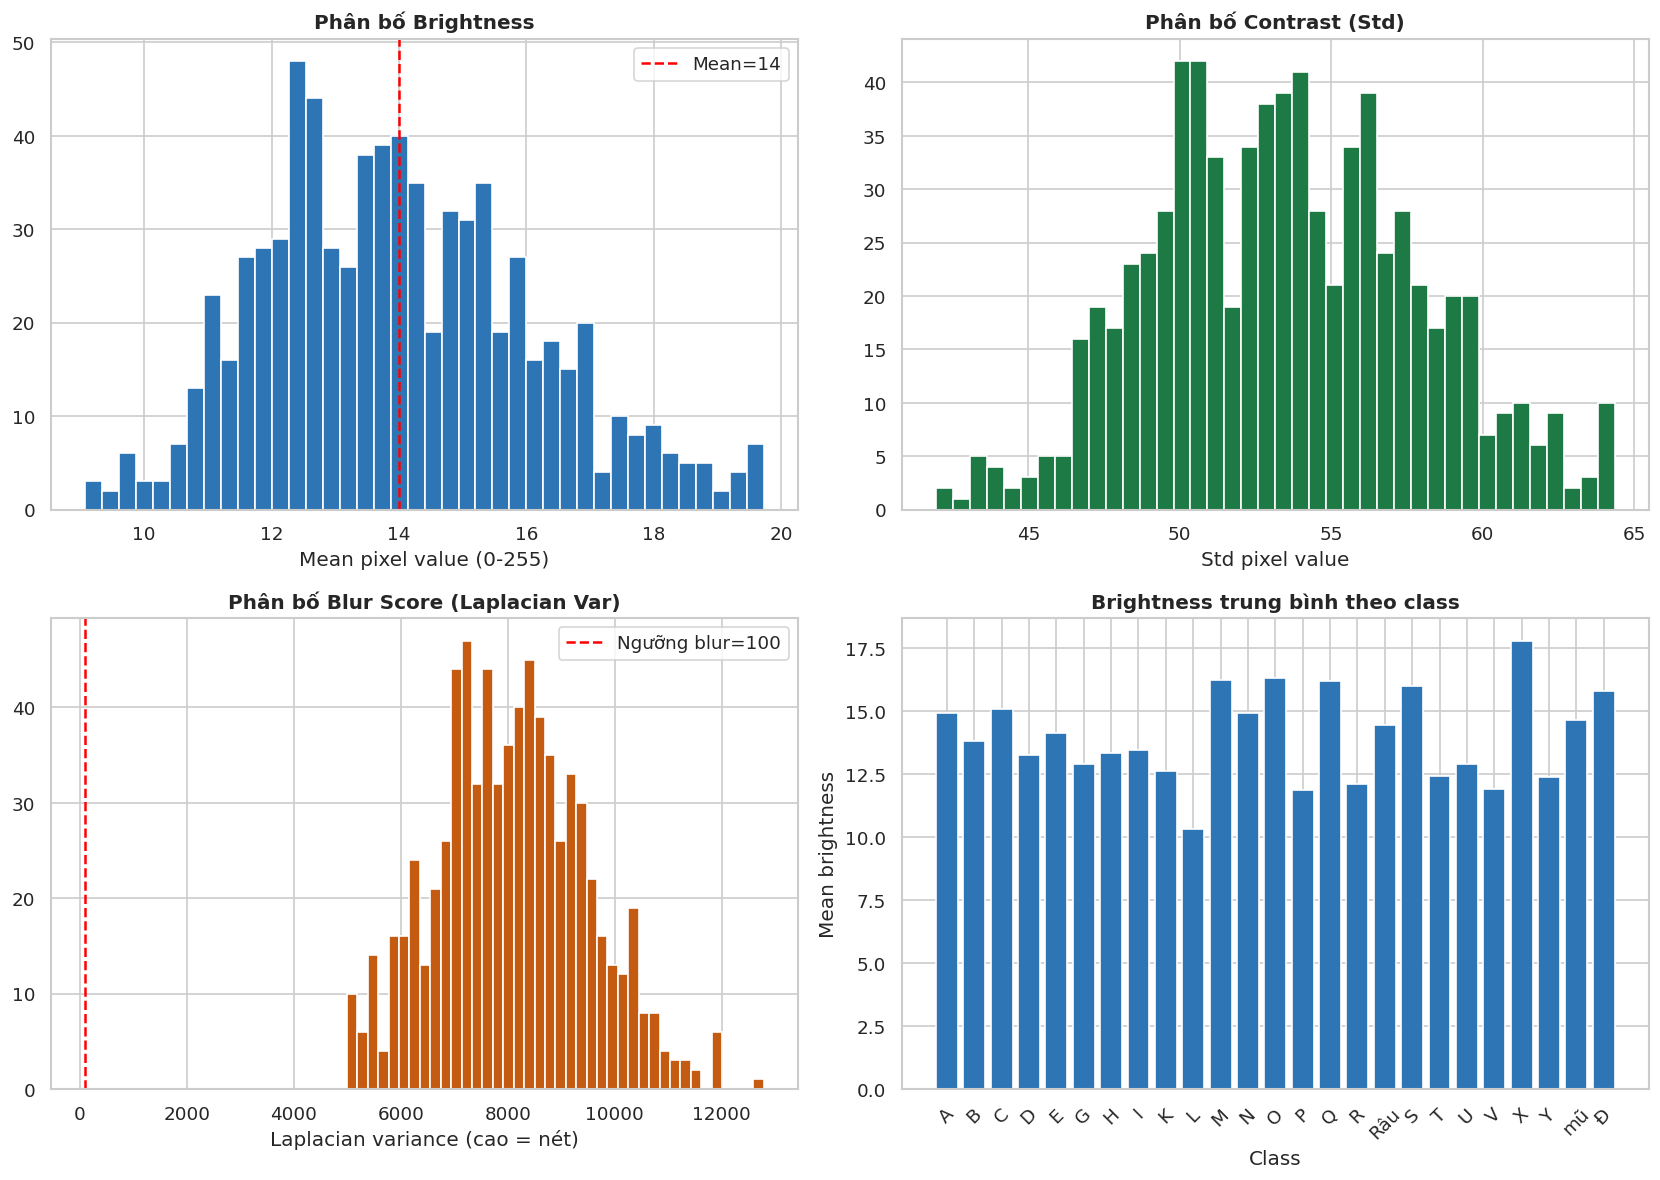

In [10]:
# ── Visualize quality metrics ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(qdf['brightness'], bins=40, color='#2E75B6', edgecolor='white')
axes[0,0].set_title('Phân bố Brightness', fontweight='bold')
axes[0,0].set_xlabel('Mean pixel value (0-255)')
axes[0,0].axvline(qdf['brightness'].mean(), color='red', linestyle='--', label=f"Mean={qdf['brightness'].mean():.0f}")
axes[0,0].legend()

axes[0,1].hist(qdf['contrast'], bins=40, color='#1D7A45', edgecolor='white')
axes[0,1].set_title('Phân bố Contrast (Std)', fontweight='bold')
axes[0,1].set_xlabel('Std pixel value')

axes[1,0].hist(qdf['blur_score'], bins=40, color='#C55A11', edgecolor='white')
axes[1,0].set_title('Phân bố Blur Score (Laplacian Var)', fontweight='bold')
axes[1,0].set_xlabel('Laplacian variance (cao = nét)')
axes[1,0].axvline(100, color='red', linestyle='--', label='Ngưỡng blur=100')
axes[1,0].legend()

# Brightness theo class
class_brightness = qdf.groupby('class')['brightness'].mean().sort_index()
axes[1,1].bar(class_brightness.index, class_brightness.values, color='#2E75B6', edgecolor='white')
axes[1,1].set_title('Brightness trung bình theo class', fontweight='bold')
axes[1,1].set_xlabel('Class')
axes[1,1].set_ylabel('Mean brightness')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUT / 'image_quality.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Xem mẫu ảnh từng class

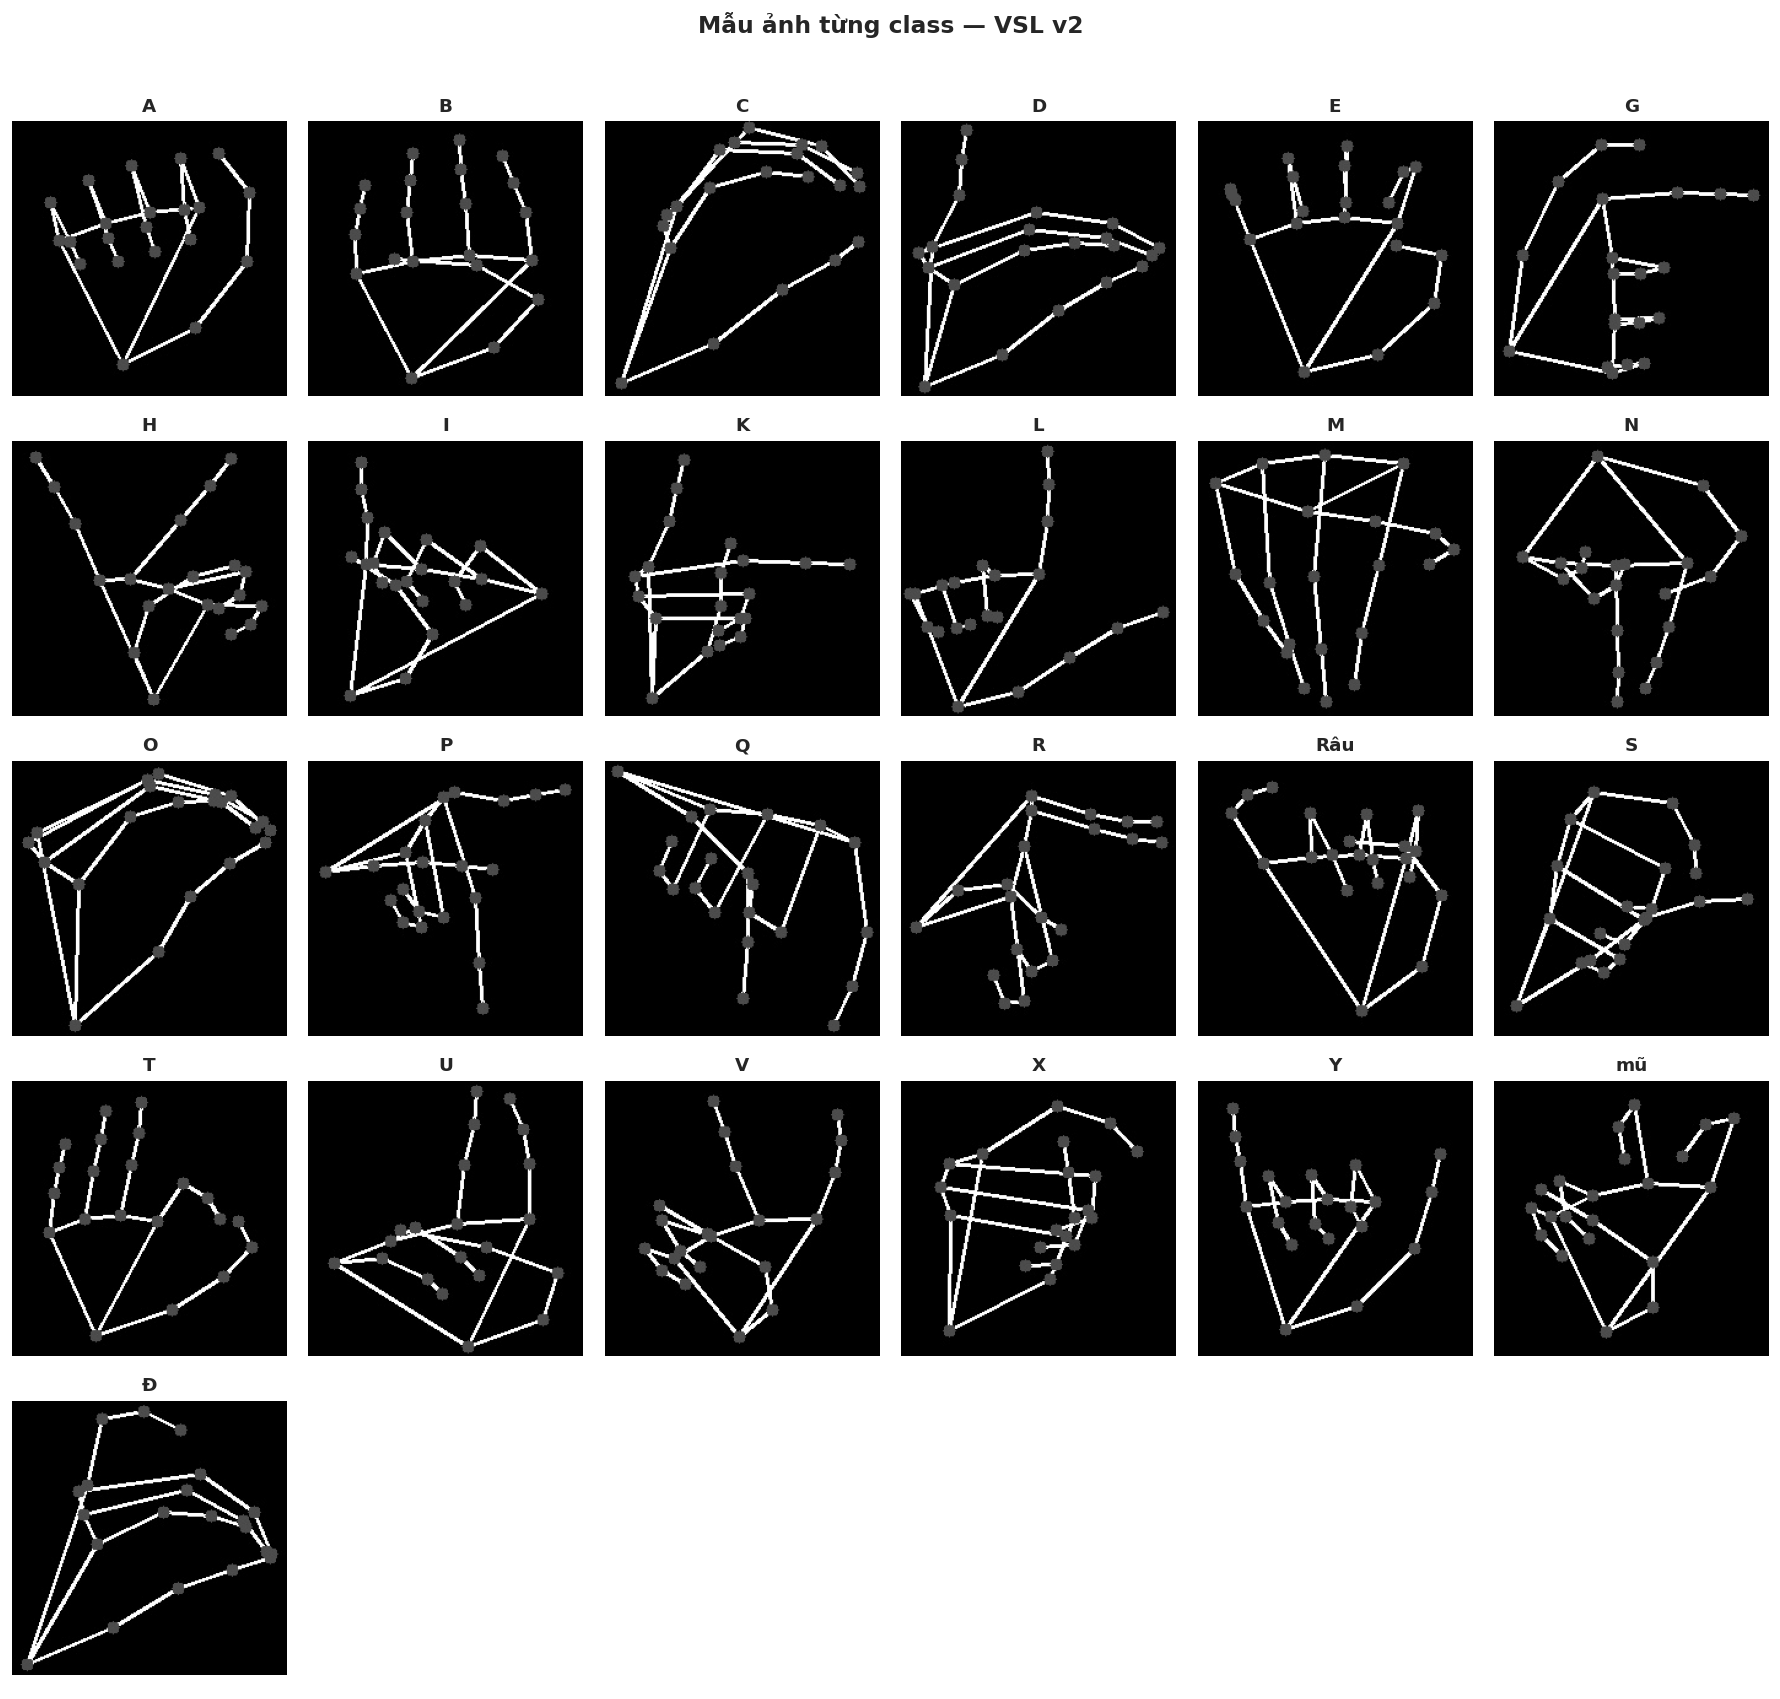

Saved: class_samples.png


In [11]:
# ── Grid ảnh mẫu — 1 ảnh mỗi class ──────────────────────────────────────
classes = sorted(df['class'].unique())
n_classes = len(classes)
n_cols = 6
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample_path = df[df['class'] == cls].sample(1, random_state=42)['path'].values[0]
    img = cv2.imread(sample_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    axes[i].set_title(cls, fontweight='bold', fontsize=11)
    axes[i].axis('off')

# Tắt axes thừa
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Mẫu ảnh từng class — VSL v2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'class_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: class_samples.png')

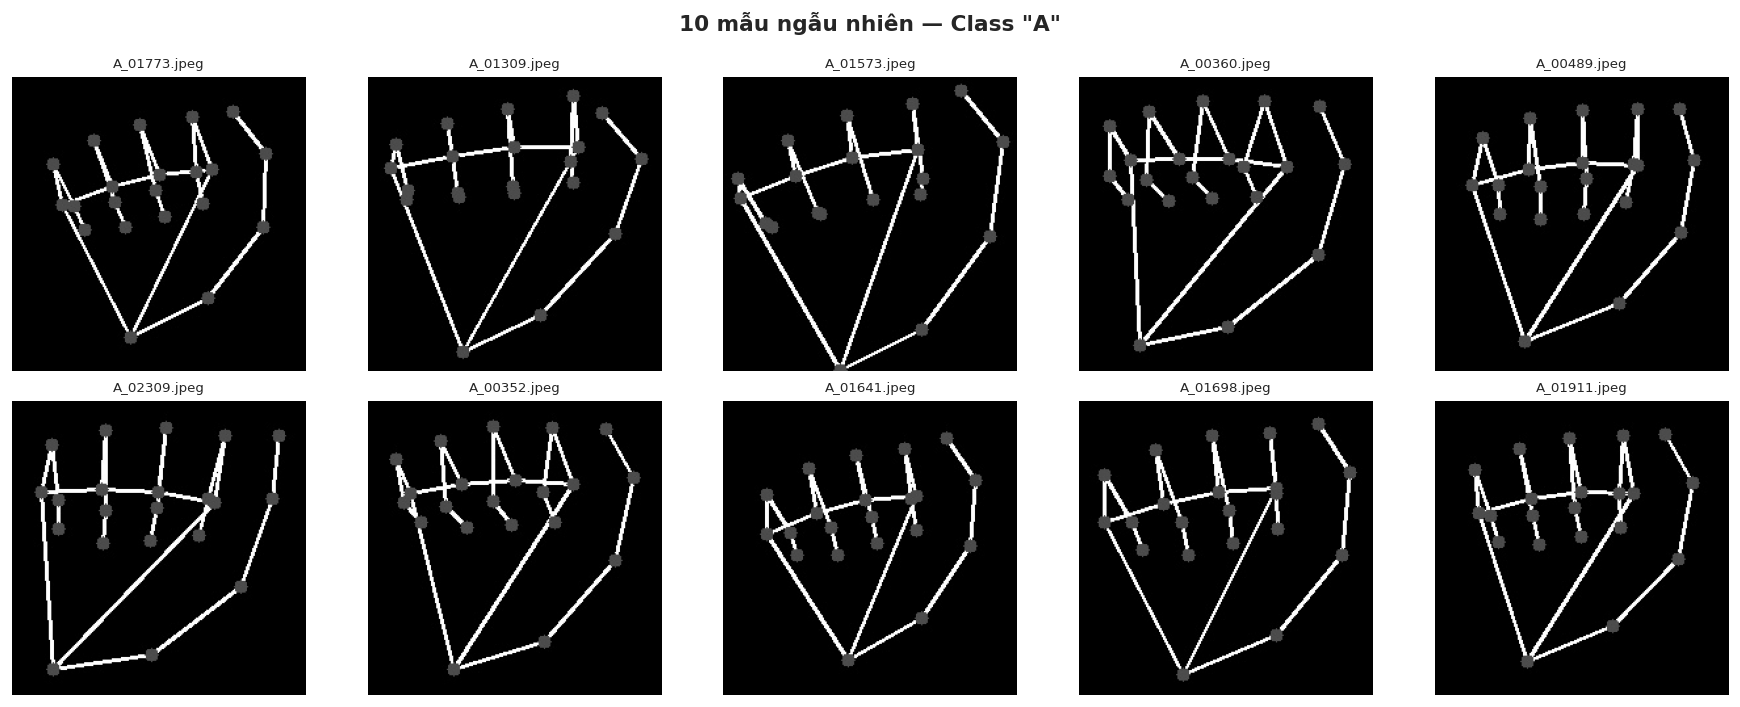

In [12]:
# ── Grid 5 ảnh mẫu cho 1 class cụ thể — kiểm tra diversity ──────────────
CHECK_CLASS = 'A'  # Thay đổi class muốn xem

class_imgs = df[df['class'] == CHECK_CLASS].sample(min(10, len(df[df['class'] == CHECK_CLASS])), random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (_, row) in enumerate(class_imgs.iterrows()):
    img = cv2.imread(row['path'])
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    axes[i].set_title(row['filename'][:15], fontsize=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'10 mẫu ngẫu nhiên — Class "{CHECK_CLASS}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / f'samples_{CHECK_CLASS}.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Phân tích Chất lượng Dữ liệu

In [13]:
# ── 7.1 Phát hiện ảnh trùng (duplicate) ──────────────────────────────────
print('Kiểm tra duplicate (MD5 hash)...')

def md5(path, chunk=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk_data := f.read(chunk):
            h.update(chunk_data)
    return h.hexdigest()

# Sample để tránh quá chậm — toàn bộ nếu dataset nhỏ
hash_sample = df.sample(min(len(df), 2000), random_state=42) if len(df) > 2000 else df

hashes = []
for _, row in tqdm(hash_sample.iterrows(), total=len(hash_sample)):
    try:
        hashes.append({'class': row['class'], 'path': row['path'], 'hash': md5(row['path'])})
    except:
        hashes.append({'class': row['class'], 'path': row['path'], 'hash': None})

hdf = pd.DataFrame(hashes)
dup_hashes = hdf[hdf.duplicated('hash', keep=False) & hdf['hash'].notna()]

print(f"""
Tổng ảnh kiểm tra  : {len(hdf)}
Ảnh trùng (duplicate): {len(dup_hashes)} ({len(dup_hashes)/len(hdf)*100:.1f}%)
Số hash trùng unique : {dup_hashes['hash'].nunique()}
""")

if len(dup_hashes) > 0:
    print('Ví dụ duplicate:')
    print(dup_hashes.groupby('hash')[['class','path']].apply(lambda x: x.values.tolist()).head(3))

Kiểm tra duplicate (MD5 hash)...


  0%|          | 0/2000 [00:00<?, ?it/s]


Tổng ảnh kiểm tra  : 2000
Ảnh trùng (duplicate): 0 (0.0%)
Số hash trùng unique : 0



In [14]:
# ── 7.2 Phát hiện ảnh ngoại lai (outlier) ────────────────────────────────
print('=' * 60)
print('PHÁT HIỆN OUTLIER')
print('=' * 60)

# Ảnh quá nhỏ (có thể thumbnail hoặc corrupt)
tiny = valid[(valid['w'] < 32) | (valid['h'] < 32)]
print(f'Ảnh quá nhỏ (<32px): {len(tiny)}')

# Ảnh có brightness cực thấp (có thể tối hoàn toàn)
dark = qdf[qdf['brightness'] < 10]
print(f'Ảnh tối hoàn toàn (brightness<10): {len(dark)}')

# Ảnh có brightness cực cao (overexposed)
bright = qdf[qdf['brightness'] > 250]
print(f'Ảnh trắng hoàn toàn (brightness>250): {len(bright)}')

# Ảnh blur nặng
blurry = qdf[qdf['blur_score'] < 20]
print(f'Ảnh quá mờ (blur_score<20): {len(blurry)}')

# File size bất thường
tiny_file = df[df['size_kb'] < 1]
large_file = df[df['size_kb'] > df['size_kb'].quantile(0.99)]
print(f'File < 1KB (nghi lỗi): {len(tiny_file)}')
print(f'File > P99 size (bất thường lớn): {len(large_file)}')

total_issues = len(tiny) + len(dark) + len(bright) + len(blurry) + len(tiny_file)
print(f'\nTổng ảnh có vấn đề tiềm tàng: {total_issues} ({total_issues/len(df)*100:.1f}%)')

PHÁT HIỆN OUTLIER
Ảnh quá nhỏ (<32px): 0
Ảnh tối hoàn toàn (brightness<10): 12
Ảnh trắng hoàn toàn (brightness>250): 0
Ảnh quá mờ (blur_score<20): 0
File < 1KB (nghi lỗi): 0
File > P99 size (bất thường lớn): 585

Tổng ảnh có vấn đề tiềm tàng: 12 (0.0%)


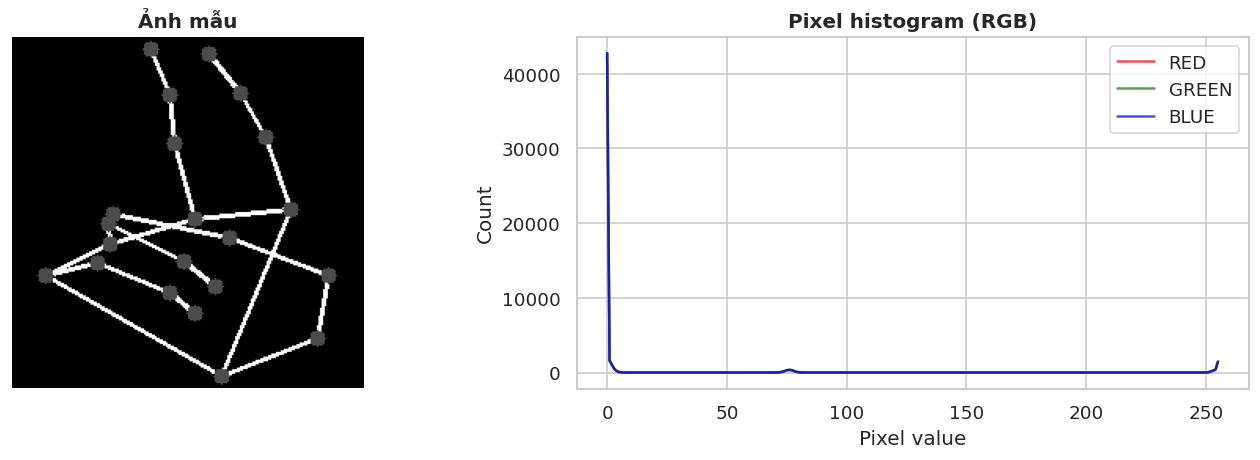

In [15]:
# ── 7.3 Phân tích pixel histogram — xác định loại ảnh ────────────────────
# Lấy 1 ảnh mẫu để xem histogram màu
sample_path = df.sample(1, random_state=7)['path'].values[0]
img_sample = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('Ảnh mẫu', fontweight='bold')
axes[0].axis('off')

colors_ch = ['red', 'green', 'blue']
for i, (ch, color) in enumerate(zip(cv2.split(img_sample[:,:,::-1]), colors_ch)):
    hist = cv2.calcHist([ch], [0], None, [256], [0,256])
    axes[1].plot(hist.flatten(), color=color, alpha=0.7, label=color.upper())

axes[1].set_title('Pixel histogram (RGB)', fontweight='bold')
axes[1].set_xlabel('Pixel value')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'pixel_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Train / Val / Test Split đề xuất

In [16]:
from sklearn.model_selection import train_test_split

# ── Stratified split ──────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print('=' * 60)
print('ĐỀ XUẤT TRAIN / VAL / TEST SPLIT')
print('=' * 60)

train_list, temp_list = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['class'], random_state=42
)
val_list, test_list = train_test_split(
    temp_list, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_list['class'], random_state=42
)

print(f"""
Train : {len(train_list):,} ảnh ({len(train_list)/len(df)*100:.1f}%)
Val   : {len(val_list):,} ảnh ({len(val_list)/len(df)*100:.1f}%)
Test  : {len(test_list):,} ảnh ({len(test_list)/len(df)*100:.1f}%)
""")

# Kiểm tra phân bố class sau split
split_check = pd.DataFrame({
    'train': train_list['class'].value_counts().sort_index(),
    'val':   val_list['class'].value_counts().sort_index(),
    'test':  test_list['class'].value_counts().sort_index(),
})
print('Phân bố class sau split:')
print(split_check.to_string())

# Cảnh báo class quá ít
min_test = split_check['test'].min()
print(f'\nSố ảnh test tối thiểu / class: {min_test}')
if min_test < 5:
    print('⚠ Một số class có < 5 ảnh test — kết quả đánh giá có thể không ổn định')

ĐỀ XUẤT TRAIN / VAL / TEST SPLIT

Train : 40,907 ảnh (70.0%)
Val   : 8,766 ảnh (15.0%)
Test  : 8,766 ảnh (15.0%)

Phân bố class sau split:
       train  val  test
class                  
A       1686  362   361
B       1688  362   362
C       1701  364   365
D       1687  362   361
E       1744  373   374
G       1697  364   364
H       1689  362   362
I       1717  368   368
K       1693  363   363
L       1687  361   362
M       1684  361   360
N       1511  324   324
O       1805  386   387
P       1766  378   379
Q       1735  372   372
R       1394  299   298
Râu     1702  365   364
S       1689  362   362
T       1690  362   362
U       1271  272   272
V       1548  332   332
X       1524  327   326
Y       1271  272   273
mũ      1644  352   352
Đ       1684  361   361

Số ảnh test tối thiểu / class: 272


In [17]:
# ── Lưu split ra file CSV ─────────────────────────────────────────────────
train_list.assign(split='train').to_csv(OUT / 'split_train.csv', index=False)
val_list.assign(split='val').to_csv(OUT / 'split_val.csv', index=False)
test_list.assign(split='test').to_csv(OUT / 'split_test.csv', index=False)

# Gộp lại 1 file
full_split = pd.concat([
    train_list.assign(split='train'),
    val_list.assign(split='val'),
    test_list.assign(split='test'),
])
full_split.to_csv(OUT / 'dataset_split.csv', index=False)
print('Saved: dataset_split.csv, split_train.csv, split_val.csv, split_test.csv')

Saved: dataset_split.csv, split_train.csv, split_val.csv, split_test.csv


## 9. Tổng hợp & Đề xuất

In [18]:
# ── Tổng hợp toàn bộ thống kê ra JSON (dùng cho báo cáo) ─────────────────
summary = {
    # Cơ bản
    'num_classes':         int(df['class'].nunique()),
    'num_images_total':    int(len(df)),
    'images_per_class_mean': float(per_class.mean()),
    'images_per_class_min':  int(per_class.min()),
    'images_per_class_max':  int(per_class.max()),
    'imbalance_ratio':     float(per_class.max() / per_class.min()),
    # Kích thước
    'img_width_mean':      float(valid['w'].mean()),
    'img_height_mean':     float(valid['h'].mean()),
    'img_width_unique':    int(valid['w'].nunique()),
    'img_height_unique':   int(valid['h'].nunique()),
    'is_uniform_size':     bool(valid['w'].nunique() == 1 and valid['h'].nunique() == 1),
    'channels_dominant':   int(valid['channels'].mode()[0]),
    'grayscale_pct':       float(valid['is_grayscale'].mean() * 100),
    # Chất lượng
    'brightness_mean':     float(qdf['brightness'].mean()),
    'brightness_std':      float(qdf['brightness'].std()),
    'contrast_mean':       float(qdf['contrast'].mean()),
    'blur_score_mean':     float(qdf['blur_score'].mean()),
    'blur_pct_under100':   float((qdf['blur_score'] < 100).mean() * 100),
    'white_bg_pct_mean':   float(qdf['white_pct'].mean()),
    'black_bg_pct_mean':   float(qdf['black_pct'].mean()),
    'corrupt_count':       int(idf['corrupt'].sum()),
    # Duplicate
    'duplicate_count':     int(len(dup_hashes)),
    'duplicate_pct':       float(len(dup_hashes) / len(hdf) * 100),
    # Split
    'split_train':         int(len(train_list)),
    'split_val':           int(len(val_list)),
    'split_test':          int(len(test_list)),
}

with open(OUT / 'eda_summary_v2.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('=' * 60)
print('TÓM TẮT EDA — VSL v2')
print('=' * 60)
for k, v in summary.items():
    print(f'  {k:<30}: {v}')

TÓM TẮT EDA — VSL v2
  num_classes                   : 25
  num_images_total              : 58439
  images_per_class_mean         : 2337.56
  images_per_class_min          : 1815
  images_per_class_max          : 2578
  imbalance_ratio               : 1.4203856749311294
  img_width_mean                : 224.0
  img_height_mean               : 224.0
  img_width_unique              : 1
  img_height_unique             : 1
  is_uniform_size               : True
  channels_dominant             : 3
  grayscale_pct                 : 100.0
  brightness_mean               : 13.995731079931973
  brightness_std                : 2.1063427165025757
  contrast_mean                 : 53.49469272074181
  blur_score_mean               : 8075.750987881394
  blur_pct_under100             : 0.0
  white_bg_pct_mean             : 4.465651573129252
  black_bg_pct_mean             : 92.20999149659862
  corrupt_count                 : 0
  duplicate_count               : 0
  duplicate_pct                 : 0.0


In [19]:
# ── Đánh giá tổng thể dataset ─────────────────────────────────────────────
print('\n' + '=' * 60)
print('ĐÁNH GIÁ TỔNG THỂ & ĐỀ XUẤT')
print('=' * 60)

issues = []
suggestions = []

# Kiểm tra cân bằng
ir = per_class.max() / per_class.min()
if ir > 3:
    issues.append(f'Mất cân bằng class: {ir:.1f}x (max={per_class.max()}, min={per_class.min()})')
    suggestions.append('Dùng WeightedRandomSampler hoặc oversampling class thiếu')

# Kiểm tra kích thước đồng nhất
if not summary['is_uniform_size']:
    issues.append(f"Kích thước ảnh không đồng nhất ({valid['w'].nunique()} width khác nhau)")
    suggestions.append('Resize toàn bộ về kích thước cố định (VD: 224x224) trong preprocessing')

# Kiểm tra ảnh blur
if summary['blur_pct_under100'] > 10:
    issues.append(f"Có {summary['blur_pct_under100']:.1f}% ảnh có blur score < 100")
    suggestions.append('Lọc bỏ hoặc kiểm tra thủ công các ảnh có blur_score < 50')

# Duplicate
if summary['duplicate_pct'] > 1:
    issues.append(f"Duplicate: {summary['duplicate_count']} ảnh ({summary['duplicate_pct']:.1f}%)")
    suggestions.append('Loại bỏ duplicate trước khi train để tránh data leakage')

# Corrupt
if summary['corrupt_count'] > 0:
    issues.append(f"Ảnh corrupt/lỗi: {summary['corrupt_count']}")
    suggestions.append('Loại bỏ ảnh không đọc được')

print('\n🔴 Vấn đề phát hiện:')
if issues:
    for i, issue in enumerate(issues, 1):
        print(f'  {i}. {issue}')
else:
    print('  ✅ Không phát hiện vấn đề nghiêm trọng')

print('\n✅ Đề xuất xử lý:')
for i, s in enumerate(suggestions, 1):
    print(f'  {i}. {s}')

print('\n💡 Đề xuất mô hình phù hợp với dataset ảnh tĩnh:')
print('  - MobileNetV2 / EfficientNet-B0: nhẹ, phù hợp deploy mobile')
print('  - MediaPipe Hands → Landmark classifier: nếu ảnh là skeleton')
print('  - CNN đơn giản nếu chỉ cần prototype/đề án')
print('  - Augmentation: RandomFlip, Rotate(±15°), ColorJitter, RandomCrop')


ĐÁNH GIÁ TỔNG THỂ & ĐỀ XUẤT

🔴 Vấn đề phát hiện:
  ✅ Không phát hiện vấn đề nghiêm trọng

✅ Đề xuất xử lý:

💡 Đề xuất mô hình phù hợp với dataset ảnh tĩnh:
  - MobileNetV2 / EfficientNet-B0: nhẹ, phù hợp deploy mobile
  - MediaPipe Hands → Landmark classifier: nếu ảnh là skeleton
  - CNN đơn giản nếu chỉ cần prototype/đề án
  - Augmentation: RandomFlip, Rotate(±15°), ColorJitter, RandomCrop
